## Load data

In [1]:
import os
import sys
import numpy as np
# load files for each season
import pickle
import pandas as pd
sys.path.append('../scripts')
from utils import average_across_days

# Choose Ecosystem and Metric
ecosystem = 'LaurentianMapleGrove'  # 'GulfStLawrence', 'LaurentianMapleGrove'
metric = 'transfer_entropy'  # 'PLV', 'coherence', 'transfer_entropy', 'wpli', 'imag_coherence'

if ecosystem == 'GulfStLawrence':
    from GulfStLawrence_info import seasons, SPRING, SUMMER, FALL, WINTER, plant_common_names, plant_distances
else:
    from LaurentianMapleGrove_info import seasons, SPRING, SUMMER, FALL, WINTER, plant_common_names, plant_distances

df_all_seasons = []
for SEASON in [SPRING, SUMMER, FALL, WINTER]:
    try:
        with open(f'../plant_data_{ecosystem}/{seasons[SEASON]}/connectivity_results_{metric}.pkl', 'rb') as f:
            dfs_results = pickle.load(f)
            df_combined, df_avg = average_across_days(dfs_results, metric=metric)
            df_avg["Season"] = SEASON
            df_all_seasons.append(df_avg)
    except FileNotFoundError:
        print(f"File not found for season {seasons[SEASON]}. Skipping...")
        continue

# Sum transfer entropy at each epoch for each season
df_all_seasons_combined = pd.concat(df_all_seasons, ignore_index=True)

# Convert epochs to hours
total_epochs = df_all_seasons_combined["Epoch"].max() + 1  # Assuming epochs span 24 hours
df_all_seasons_combined["Hour"] = df_all_seasons_combined["Epoch"] / total_epochs * 24
df_all_seasons_combined['Season name'] = df_all_seasons_combined['Season'].map({SPRING: 'Spring', SUMMER: 'Summer', FALL: 'Fall', WINTER: 'Winter'})

df_distances = pd.DataFrame(list(plant_distances.items()), columns=["Plant_Pair", "Distance"])
df_distances[["Plant1", "Plant2"]] = pd.DataFrame(df_distances["Plant_Pair"].tolist(), index=df_distances.index)
df_distances = df_distances.drop(columns=["Plant_Pair"])

## Mixed effect model

In [2]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Define the seasons for analysis
seasons_list = list(seasons.keys())

# Initialize an empty list to store model results
results_list = []

# Iterate over each season and fit the Linear Mixed Model (LMM)
for season in seasons_list:
    df_avg = df_all_seasons_combined[df_all_seasons_combined["Season"] == season]
    # normalize distance and transfer entropy
    
    df_avg[metric] = (df_avg[metric] - df_avg[metric].mean()) / df_avg[metric].std()

    # Merge distances with entropy
    df_correlation = df_avg.merge(df_distances, on=["Plant1", "Plant2"], how="inner")
    df_correlation["Distance"] = (df_correlation["Distance"] - df_correlation["Distance"].mean()) / df_correlation["Distance"].std()
    # Fit the Linear Mixed Model
    model = smf.mixedlm(f"Q('{metric}') ~ Distance", df_correlation, groups=df_correlation["Plant1"])
    result = model.fit()

    # Extract relevant values
    coef_distance = result.params["Distance"]
    p_value_distance = result.pvalues["Distance"]
    intercept = result.params["Intercept"]
    aic = result.aic

    # Store results in a dictionary
    results_list.append({
        "Season": season,
        "Intercept": intercept,
        "Distance Coefficient": coef_distance,
        "P-value (Distance)": p_value_distance,
        #"AIC": aic
    })

# Convert results to a DataFrame
df_results_summary = pd.DataFrame(results_list)

# Display the results table
print(df_results_summary)


     Season  Intercept  Distance Coefficient  P-value (Distance)
0   Serie 3  -0.660903             -0.629000       1.463143e-129
1  Serie 29   0.061683             -0.013399        8.033226e-01
2  Serie 36   0.291141              0.426774        4.905235e-09
3   Serie 2  -0.021343              0.185931        7.426390e-03


C:\Users\skite\AppData\Local\Temp\ipykernel_36500\1952470575.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_avg[metric] = (df_avg[metric] - df_avg[metric].mean()) / df_avg[metric].std()
C:\Users\skite\AppData\Local\Temp\ipykernel_36500\1952470575.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_avg[metric] = (df_avg[metric] - df_avg[metric].mean()) / df_avg[metric].std()
C:\Users\skite\AppData\Local\Temp\ipykernel_36500\1952470575.py:16: SettingWithCopyWarning: 
A value is trying to be set o

In [3]:
df_results_summary

,Season,Intercept,Distance Coefficient,P-value (Distance)
0,Serie 3,-0.660903,-0.629000,1.463143e-129
1,Serie 29,0.061683,-0.013399,8.033226e-01
2,Serie 36,0.291141,0.426774,4.905235e-09
3,Serie 2,-0.021343,0.185931,7.426390e-03


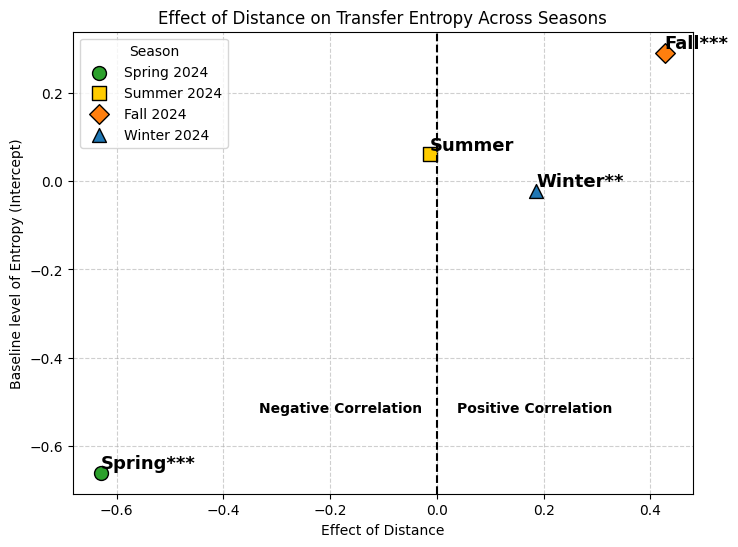

In [4]:
import matplotlib.pyplot as plt
import numpy as np

df_results_summary["Season"] = df_results_summary["Season"].replace(seasons)
# Define season colors and markers
season_mapping = seasons.copy()
season_colors = {v: c for k, v, c in zip(season_mapping.keys(), season_mapping.values(), ["#2ca02c", "#ffcc00", "#ff7f0e", "#1f77b4"])}

season_markers = {v: c for k, v, c in zip(season_mapping.keys(), season_mapping.values(), ["o", "s", "D", "^"])}  # Circle, Square, Diamond, Triangle

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot for Intercept vs Distance Coefficient
for i, row in df_results_summary.iterrows():
    ax.scatter(row["Distance Coefficient"], row["Intercept"],
               color=season_colors[row["Season"]],
               marker=season_markers[row["Season"]],
               s=100, label=row["Season"], edgecolors="black")

# Add annotations
for i, row in df_results_summary.iterrows():
    if row["P-value (Distance)"] < 0.001:
        # Annotate extremely significant points with asterisks
        ax.text(row["Distance Coefficient"], row["Intercept"], row["Season"].split()[0] + '***',
                fontsize=13, ha="left", va="bottom", fontweight="bold")
    elif row["P-value (Distance)"] < 0.01:
        # Annotate highly significant points with asterisks
        ax.text(row["Distance Coefficient"], row["Intercept"], row["Season"].split()[0] + '**',
                fontsize=13, ha="left", va="bottom", fontweight="bold")
    elif row["P-value (Distance)"] < 0.05:
        # Annotate significant points with asterisks
        ax.text(row["Distance Coefficient"], row["Intercept"], row["Season"].split()[0] + '*',
                fontsize=13, ha="left", va="bottom", fontweight="bold")
    
    
    else:
        # Annotate non-significant points without asterisks
        ax.text(row["Distance Coefficient"], row["Intercept"], row["Season"].split()[0],
                fontsize=13, ha="left", va="bottom", fontweight="bold")
    # ax.text(row["Distance Coefficient"], row["Intercept"], row["Season"].split()[0] + '***',
    #         fontsize=13, ha="left", va="bottom", fontweight="bold")

# Add grid
ax.grid(True, linestyle="--", alpha=0.6)

# Labels and title
ax.set_xlabel("Effect of Distance")
ax.set_ylabel("Baseline level of Entropy (Intercept)")
ax.set_title("Effect of Distance on Transfer Entropy Across Seasons")

# Remove duplicate legends
handles, labels = ax.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax.legend(unique_labels.values(), unique_labels.keys(), title="Season", loc="best")
# add black line at 0
ax.axvline(x=0, color='black', linestyle='--')
# write 'positive correlation' and 'negative correlation'
if ecosystem == 'GulfStLawrence':
    ax.text(0.32, 0.2, 'Positive Correlation', transform=ax.transAxes, fontsize=10, verticalalignment='top', fontweight="bold")
    ax.text(0.02, 0.2, 'Negative Correlation', transform=ax.transAxes, fontsize=10, verticalalignment='top', fontweight="bold")
else:  
    ax.text(0.62, 0.2, 'Positive Correlation', transform=ax.transAxes, fontsize=10, verticalalignment='top', fontweight="bold")
    ax.text(0.3, 0.2, 'Negative Correlation', transform=ax.transAxes, fontsize=10, verticalalignment='top', fontweight="bold")
# Show plot
plt.show()


## LMM including season as a variable

In [13]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Normalize Distance and Transfer Entropy across all seasons
df_all_seasons_combined[metric] = (
    df_all_seasons_combined[metric] - df_all_seasons_combined[metric].mean()
) / df_all_seasons_combined[metric].std()

# Merge distances with entropy
df_correlation = df_all_seasons_combined.merge(df_distances, on=["Plant1", "Plant2"], how="inner")

df_correlation["Distance"] = (df_correlation["Distance"] - df_correlation["Distance"].mean()) / df_correlation["Distance"].std()

df_correlation["Season"] = df_correlation["Season"].map(season_mapping)
# Fit a single Linear Mixed Model (LMM)
model = smf.mixedlm(
    f"Q('{metric}') ~ Distance * C(Season)",  # Main effects + Interaction
    df_correlation,
    groups=df_correlation["Plant1"],  # Plants as random intercepts
)
result = model.fit()

# Print results
print(result.summary())


                    Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    Q('transfer_entropy')
No. Observations:     3003       Method:                REML                 
No. Groups:           3          Scale:                 0.5981               
Min. group size:      429        Log-Likelihood:        -3508.7857           
Max. group size:      1573       Converged:             Yes                  
Mean group size:      1001.0                                                 
-----------------------------------------------------------------------------
                                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                          0.294    0.099   2.985 0.003  0.101  0.487
C(Season)[T.Spring 2024]          -0.813    0.050 -16.298 0.000 -0.911 -0.715
C(Season)[T.Summer 2024]          -0.743    0.037 -19.877 0.000 -0.816 -0.670
C(Seas

# test slope of each season

In [18]:
import numpy as np

# 1) Fixed‐effect names (exclude Group Var)
fe_names = result.fe_params.index.tolist()

def slope_test(season_label):
    # Build 1×k_fe contrast R: Distance + Distance×Season[season_label]
    R = np.zeros((1, len(fe_names)))
    R[0, fe_names.index("Distance")] = 1.0
    term = f"Distance:C(Season)[T.{season_label}]"
    R[0, fe_names.index(term)] = 1.0

    # Run the Wald t‐test
    ct = result.t_test(R)
    est = ct.effect[0]   # net slope estimate
    se  = ct.sd[0]       # standard error
    p   = ct.pvalue      # two‐sided p‐value (array of length 1)
    return float(est), float(se), float(p)

# Fall (baseline)
est_fall = result.fe_params["Distance"]
se_fall  = result.bse_fe["Distance"]
p_fall   = result.pvalues["Distance"]

# Spring, Summer, Winter
est_spr, se_spr, p_spr = slope_test("Spring 2024")
est_sum, se_sum, p_sum = slope_test("Summer 2024")
est_win, se_win, p_win = slope_test("Winter 2024")

# Print summary
print("Season   Estimate   SE       p-value")
print(f"Fall     {est_fall:8.3f}  {se_fall:6.3f}  {p_fall:.3e}")
print(f"Spring   {est_spr:8.3f}  {se_spr:6.3f}  {p_spr:.3e}")
print(f"Summer   {est_sum:8.3f}  {se_sum:6.3f}  {p_sum:.3e}")
print(f"Winter   {est_win:8.3f}  {se_win:6.3f}  {p_win:.3e}")


Season   Estimate   SE       p-value
Fall        0.333   0.039  6.300e-18
Spring     -1.189   0.061  1.973e-84
Summer     -0.103   0.039  7.898e-03
Winter      0.324   0.039  5.232e-17


C:\Users\skite\AppData\Local\Temp\ipykernel_36500\3452488560.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(est), float(se), float(p)


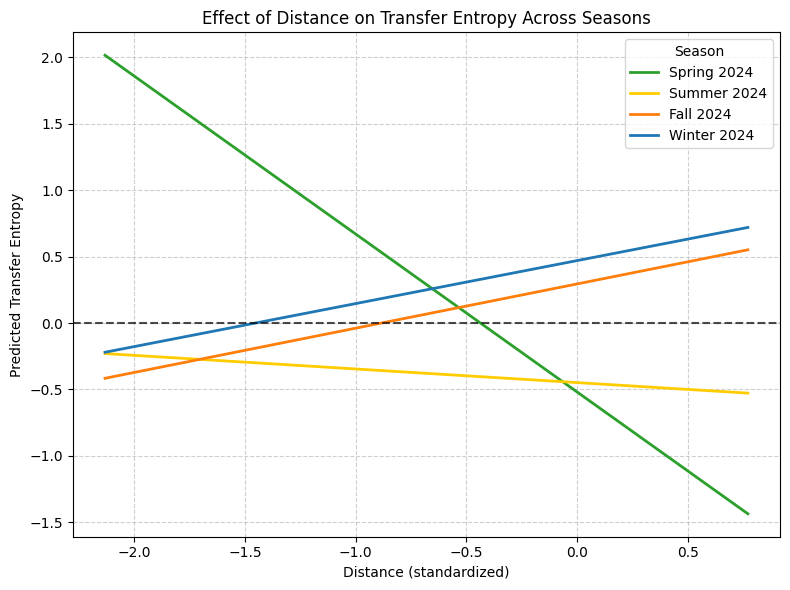

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Prepare prediction grid ---

# 1) Get the unique seasons and ensure they stay in the original order
season_levels = df_correlation["Season"].dropna().unique()
seasons = pd.Categorical(season_levels, categories=season_levels, ordered=True)

# 2) Create a smooth range of Distance values (standardized)
distance_grid = np.linspace(
    df_correlation["Distance"].min(),
    df_correlation["Distance"].max(),
    100
)

# 3) Build the DataFrame for prediction
pred_df = pd.DataFrame([
    {"Distance": d, "Season": s}
    for d in distance_grid
    for s in seasons
])
pred_df["Season"] = pd.Categorical(pred_df["Season"], categories=season_levels, ordered=True)

# --- Predict ---

pred_df["Predicted_TE"] = result.predict(pred_df)

# --- Plotting ---

# Define colors for each season
season_colors = {v: c for k, v, c in zip(season_mapping.keys(), season_mapping.values(), ["#2ca02c", "#ffcc00", "#ff7f0e", "#1f77b4"])}

fig, ax = plt.subplots(figsize=(8, 6))

for season in season_levels:
    mask = pred_df["Season"] == season
    ax.plot(
        pred_df.loc[mask, "Distance"],
        pred_df.loc[mask, "Predicted_TE"],
        label=season,
        color=season_colors.get(season, None),
        linewidth=2
    )

# Add baseline, labels, legend, grid
ax.axhline(0, linestyle="--", color="black", alpha=0.7)
ax.set_xlabel("Distance (standardized)")
ax.set_ylabel("Predicted Transfer Entropy")
ax.set_title("Effect of Distance on Transfer Entropy Across Seasons")
ax.legend(title="Season")
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


## !!!EXPLORATORY!!!

In [37]:
model = smf.mixedlm(
    f"Q('{metric}') ~ Distance * C(Season) + C(Plant1)",  
    df_correlation,
    groups=df_correlation["Plant2"],
    re_formula="~ Distance"  
)

result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                    Mixed Linear Model Regression Results
=============================================================================
Model:                MixedLM    Dependent Variable:    Q('transfer_entropy')
No. Observations:     3003       Method:                REML                 
No. Groups:           3          Scale:                 0.5229               
Min. group size:      572        Log-Likelihood:        -3312.1177           
Max. group size:      1287       Converged:             Yes                  
Mean group size:      1001.0                                                 
-----------------------------------------------------------------------------
                                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                         -0.035                                     
C(Season)[T.Spring 2024]          -1.017    0.048 -21.227 0.000 -1.111 -0.923
C(Season)[T.Summer 2024]          -0.743    0.035 -21.259 0.000 -0.811 -0.674
C(Season)[T.Winter 2024]           0.176    0.035   5.031 0.000  0.107  0.244
C(Plant1)[T.3]                     3.145                                     
C(Plant1)[T.7]                     0.285                                     
Distance                           0.932                                     
Distance:C(Season)[T.Spring 2024] -1.708    0.068 -25.188 0.000 -1.841 -1.575
Distance:C(Season)[T.Summer 2024] -0.436    0.033 -13.026 0.000 -0.501 -0.370
Distance:C(Season)[T.Winter 2024] -0.009    0.033  -0.284 0.777 -0.075  0.056
Group Var                          0.429                                     
Group x Distance Cov              -0.242    0.521                            
Distance Var                       0.136                                     
=============================================================================

"""

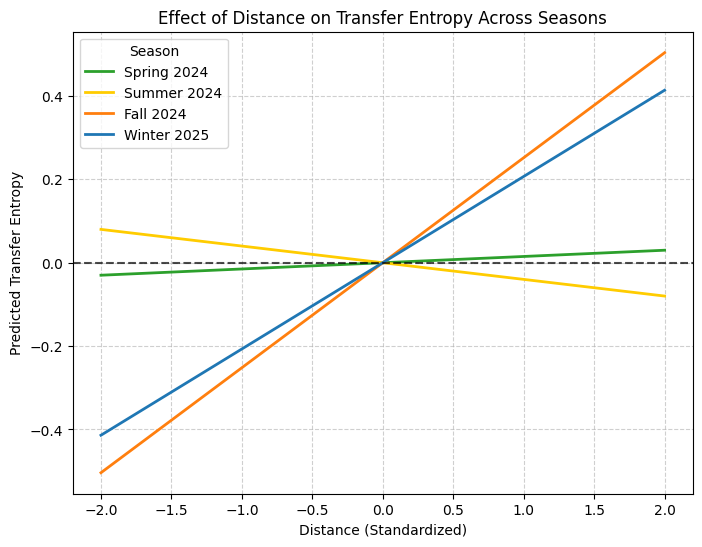

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define season colors
season_colors = {
    "Spring 2024": "#2ca02c",
    "Summer 2024": "#ffcc00",
    "Fall 2024": "#ff7f0e",
    "Winter 2025": "#1f77b4"
}

# Extract slopes for each season
base_slope = 0.252  # Distance main effect
season_slopes = {
    "Spring 2024": base_slope - 0.237,
    "Summer 2024": base_slope - 0.292,
    "Fall 2024": base_slope,  # Reference category
    "Winter 2025": base_slope - 0.045
}

# Generate standardized distance values
distances = np.linspace(-2, 2, 100)

# Plot results
plt.figure(figsize=(8, 6))
for season, slope in season_slopes.items():
    plt.plot(distances, slope * distances, label=season, color=season_colors[season], linewidth=2)

plt.axhline(0, linestyle="--", color="black", alpha=0.7)
plt.xlabel("Distance (Standardized)")
plt.ylabel("Predicted Transfer Entropy")
plt.title("Effect of Distance on Transfer Entropy Across Seasons")
plt.legend(title="Season")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


In [40]:
result.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                    Mixed Linear Model Regression Results
=============================================================================
Model:                MixedLM    Dependent Variable:    Q('transfer_entropy')
No. Observations:     3003       Method:                REML                 
No. Groups:           3          Scale:                 0.5229               
Min. group size:      572        Log-Likelihood:        -3312.1177           
Max. group size:      1287       Converged:             Yes                  
Mean group size:      1001.0                                                 
-----------------------------------------------------------------------------
                                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                         -0.035                                     
C(Season)[T.Spring 2024]          -1.017    0.048 -21.227 0.000 -1.111 -0.923
C(Season)[T.Summer 2024]          -0.743    0.035 -21.259 0.000 -0.811 -0.674
C(Season)[T.Winter 2024]           0.176    0.035   5.031 0.000  0.107  0.244
C(Plant1)[T.3]                     3.145                                     
C(Plant1)[T.7]                     0.285                                     
Distance                           0.932                                     
Distance:C(Season)[T.Spring 2024] -1.708    0.068 -25.188 0.000 -1.841 -1.575
Distance:C(Season)[T.Summer 2024] -0.436    0.033 -13.026 0.000 -0.501 -0.370
Distance:C(Season)[T.Winter 2024] -0.009    0.033  -0.284 0.777 -0.075  0.056
Group Var                          0.429                                     
Group x Distance Cov              -0.242    0.521                            
Distance Var                       0.136                                     
=============================================================================

"""

C:\Users\skite\AppData\Local\Temp\ipykernel_6772\2644188353.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Effect", y="Plant", data=df_plant_effects, palette="coolwarm", edgecolor="black")


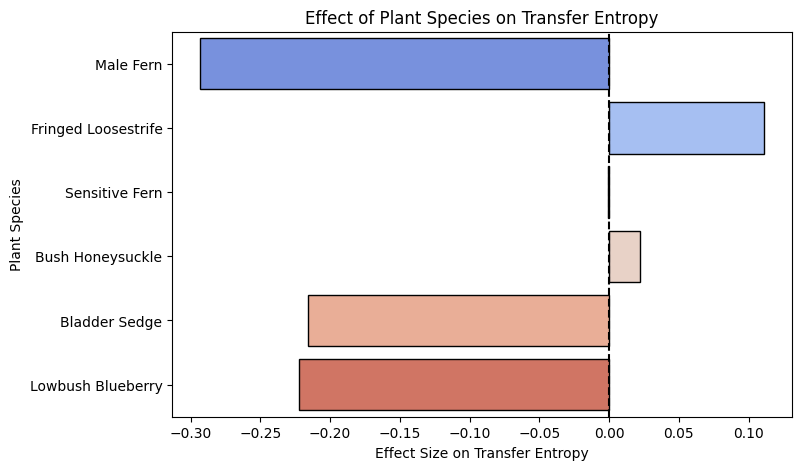

In [ ]:
import seaborn as sns

# Mapping of plant indices to names
plant_names = {
    1: "Male Fern",
    2: "Fringed Loosestrife",
    3: "Sensitive Fern",
    4: "Bush Honeysuckle",
    5: "Bladder Sedge",
    6: "Lowbush Blueberry",
}

# Extract coefficients for plants
plant_effects = {
    "Male Fern": -0.293,
    "Fringed Loosestrife": 0.111,
    "Sensitive Fern": -0.001,
    "Bush Honeysuckle": 0.022,
    "Bladder Sedge": -0.216,
    "Lowbush Blueberry": -0.222,
}

# Convert to DataFrame
df_plant_effects = pd.DataFrame(plant_effects.items(), columns=["Plant", "Effect"])

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x="Effect", y="Plant", data=df_plant_effects, palette="coolwarm", edgecolor="black")

plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Effect Size on Transfer Entropy")
plt.ylabel("Plant Species")
plt.title("Effect of Plant Species on Transfer Entropy")
plt.show()
